# B5 — Machine Learning tabulaire : prédire la panne

Premier modèle de **classification binaire** (« panne dans les prochaines Hh ? ») à partir
du **gold** InduSense (`gold.dataset` / `data/processed/gold_dataset.parquet`) — **pas** du
dataset générique décrit dans le brief du TP (`b5_maintenance_ml.md`) : on repart de notre
schéma réel.

**Deux pièges à éviter** : la **fuite temporelle** (split chronologique existant, pas de
split aléatoire ; RUL et les 3 autres horizons exclus des features à chaque fois) et le
**déséquilibre de classes** (de 4,3 % de positifs à 6h à 25,1 % à 48h — PR-AUC en métrique
primaire, jamais l'accuracy seule).

**Les 4 horizons du gold** (`config.LABEL_HORIZONS`) sont comparés ici : **6h / 12h / 24h /
48h**. Chaque horizon est un problème de classification différent (déséquilibre croissant
avec l'horizon), avec son propre gagnant et son propre temps d'entraînement.

> **Prérequis** : couche gold construite (`03_gold.ipynb` / `uv run indusense-gold`).

## 1. Entraînement — 4 horizons

Pour chaque horizon (`config.LABEL_HORIZONS`), équivalent de `uv run indusense-train
--horizon H` : charge le gold, construit 3 pipelines (régression logistique, Random Forest,
XGBoost — prétraitement fit-train : imputation médiane, standardisation, one-hot), les
évalue sur le split test, et lance une validation croisée temporelle (`TimeSeriesSplit`)
pour une estimation robuste. Le temps d'entraînement (mur, `time.perf_counter`) est mesuré
pour chaque horizon.

In [1]:
import time

from indusense import config
from indusense.ml import training

runs_by_horizon = {}
durations = {}
for h in config.LABEL_HORIZONS:
    t0 = time.perf_counter()
    runs_by_horizon[h] = training.run(horizon=h)
    durations[h] = time.perf_counter() - t0
    meta = runs_by_horizon[h]
    print(f"horizon={h:>2}h  run={meta['run_id']}  gagnant={meta['winner']:<14} "
          f"PR-AUC={meta['pr_auc_test']:.4f}  temps={durations[h]:.1f}s")

horizon= 6h  run=202607070900  gagnant=xgboost        PR-AUC=0.3434  temps=261.5s


horizon=12h  run=202607070904  gagnant=xgboost        PR-AUC=0.3738  temps=345.7s


horizon=24h  run=202607070910  gagnant=xgboost        PR-AUC=0.4495  temps=313.5s


horizon=48h  run=202607070915  gagnant=logreg         PR-AUC=0.4495  temps=317.5s


## 2. Temps d'entraînement

Temps mur (wall-clock, `time.perf_counter`) de `training.run(horizon=h)` : 3 pipelines
fittés sur train + évalués sur test + validation croisée temporelle à 5 folds (5 refits par
modèle) + logging MLflow. Comparable entre horizons (même volumétrie de features, seul le
label change).

In [2]:
import pandas as pd

summary = pd.DataFrame([
    {
        "horizon_h": h,
        "run_id": runs_by_horizon[h]["run_id"],
        "gagnant": runs_by_horizon[h]["winner"],
        "pr_auc_test": runs_by_horizon[h]["pr_auc_test"],
        "roc_auc_test": runs_by_horizon[h]["roc_auc_test"],
        "temps_entrainement_s": round(durations[h], 1),
    }
    for h in config.LABEL_HORIZONS
])
summary

,horizon_h,run_id,gagnant,pr_auc_test,roc_auc_test,temps_entrainement_s
0,6,202607070900,xgboost,0.3434,0.7830,261.5
1,12,202607070904,xgboost,0.3738,0.7419,345.7
2,24,202607070910,xgboost,0.4495,0.7098,313.5
3,48,202607070915,logreg,0.4495,0.6593,317.5


## 3. Résultats par horizon

Pour chaque horizon : le tableau comparatif complet (trié par PR-AUC) puis les 3 figures
(comparaison PR-AUC/ROC-AUC, matrice de confusion du gagnant, PR-AUC en validation croisée
temporelle).

### Horizon 6h — gagnant : **xgboost** (PR-AUC=0.3434, ROC-AUC=0.783)

,model,pr_auc_test,roc_auc_test,pr_auc_cv_mean,pr_auc_cv_std,precision,recall,f1,tn,fp,fn,tp
0,xgboost,0.343358,0.782973,0.316002,0.056066,0.439935,0.317330,0.368707,18454,345,583,271
1,random_forest,0.272561,0.778594,0.271419,0.063319,0.875000,0.032787,0.063205,18795,4,826,28
2,logreg,0.225902,0.732814,0.197112,0.038461,0.088735,0.617096,0.155160,13387,5412,327,527


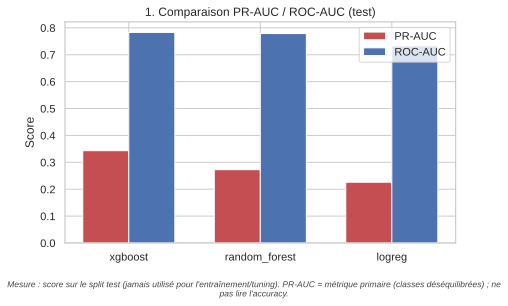

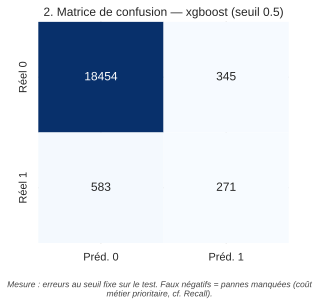

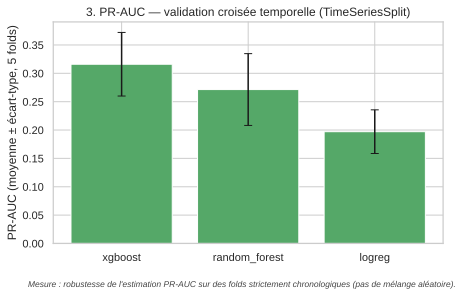

### Horizon 12h — gagnant : **xgboost** (PR-AUC=0.3738, ROC-AUC=0.7419)

,model,pr_auc_test,roc_auc_test,pr_auc_cv_mean,pr_auc_cv_std,precision,recall,f1,tn,fp,fn,tp
0,xgboost,0.373801,0.741903,0.334030,0.054340,0.440256,0.364976,0.399097,17170,787,1077,619
1,random_forest,0.320671,0.756936,0.311270,0.062313,0.687500,0.084316,0.150210,17892,65,1553,143
2,logreg,0.315417,0.728697,0.256477,0.048974,0.159013,0.653302,0.255771,12097,5860,588,1108


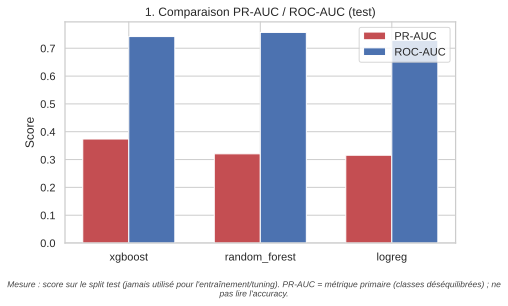

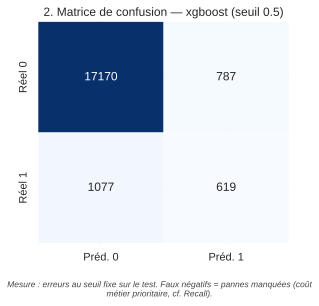

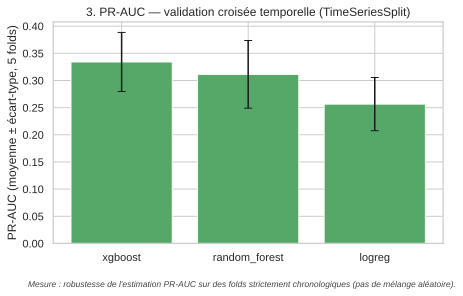

### Horizon 24h — gagnant : **xgboost** (PR-AUC=0.4495, ROC-AUC=0.7098)

,model,pr_auc_test,roc_auc_test,pr_auc_cv_mean,pr_auc_cv_std,precision,recall,f1,tn,fp,fn,tp
0,xgboost,0.449497,0.709803,0.393020,0.041143,0.449093,0.389477,0.417166,14766,1580,2019,1288
1,logreg,0.428257,0.716126,0.353781,0.053192,0.269401,0.661324,0.382845,10415,5931,1120,2187
2,random_forest,0.422528,0.739065,0.401541,0.040938,0.673333,0.213789,0.324535,16003,343,2600,707


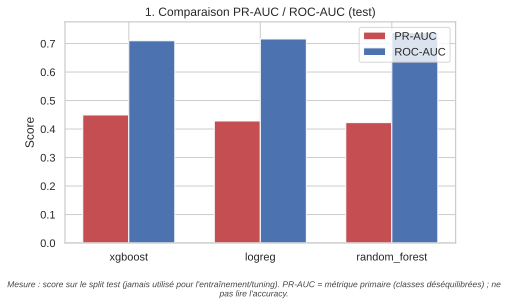

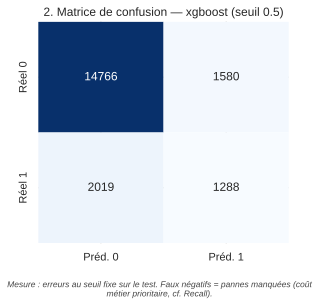

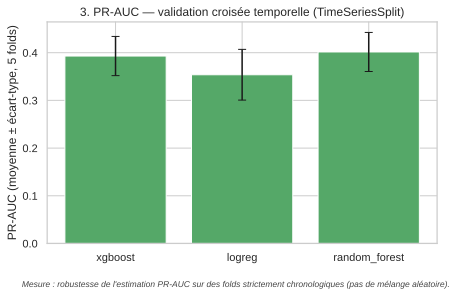

### Horizon 48h — gagnant : **logreg** (PR-AUC=0.4495, ROC-AUC=0.6593)

,model,pr_auc_test,roc_auc_test,pr_auc_cv_mean,pr_auc_cv_std,precision,recall,f1,tn,fp,fn,tp
0,logreg,0.449499,0.659324,0.389340,0.033616,0.336543,0.598630,0.430861,8833,5857,1992,2971
1,xgboost,0.436614,0.635510,0.378455,0.050963,0.415385,0.380818,0.397351,12030,2660,3073,1890
2,random_forest,0.430954,0.676649,0.389331,0.056322,0.539338,0.200282,0.292095,13841,849,3969,994


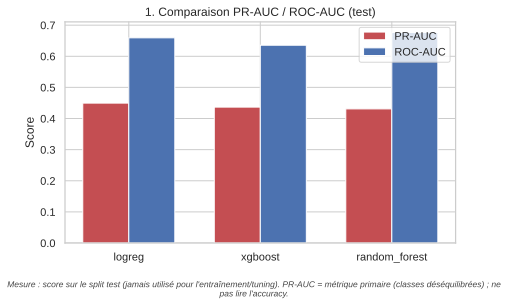

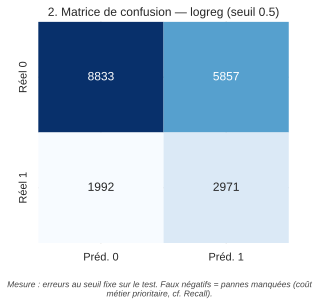

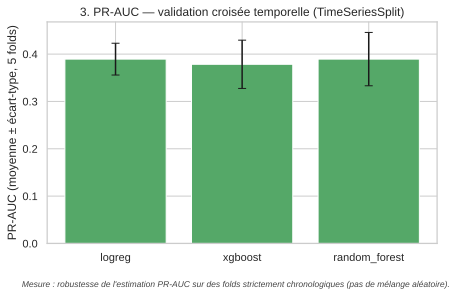

In [3]:
from pathlib import Path

from IPython.display import SVG, Markdown, display

for h in config.LABEL_HORIZONS:
    meta = runs_by_horizon[h]
    display(Markdown(
        f"### Horizon {h}h — gagnant : **{meta['winner']}** "
        f"(PR-AUC={meta['pr_auc_test']}, ROC-AUC={meta['roc_auc_test']})"
    ))
    display(pd.DataFrame(meta["comparison"]))
    run_dir = Path(meta["chemin"])
    for fig in sorted((run_dir / "figures").glob("*.svg")):
        display(SVG(filename=str(fig)))

## 4. MLflow

Chaque modèle, pour chaque horizon (12 runs au total : 4 horizons × 3 modèles), est loggé
(params dont `horizon`, métriques, figure de confusion, pipeline) dans la même expérience
MLflow locale (backend SQLite, `artifacts/ml/mlflow.db`, non versionné) — filtrable par le
paramètre `horizon` dans l'UI.

Pour explorer les runs :

```bash
uv run mlflow ui --backend-store-uri sqlite:///artifacts/ml/mlflow.db
```

## 5. Explication des métriques

### Colonnes du tableau comparatif (par horizon)

| Colonne | Signification |
|---|---|
| `model` | Nom du pipeline (`logreg`, `random_forest`, `xgboost`). |
| `pr_auc_test` | **PR-AUC** (Average Precision) sur le split **test** — métrique **primaire** : robuste au déséquilibre de classes, contrairement à l'accuracy. |
| `roc_auc_test` | ROC-AUC sur le split test — métrique **secondaire**, complémentaire mais plus optimiste que la PR-AUC quand les classes sont déséquilibrées. |
| `pr_auc_cv_mean` / `pr_auc_cv_std` | Moyenne / écart-type de la PR-AUC sur 5 folds de **validation croisée temporelle** (`TimeSeriesSplit`, triée par horodatage seul) — estime la **robustesse** du score au-delà du seul split test (un score test isolé peut être optimiste ou pessimiste par chance). |
| `precision` | Parmi les alertes émises (au seuil 0.5), proportion de vraies pannes. Une precision basse = beaucoup de **fausses alertes**. |
| `recall` | Parmi les pannes réelles, proportion détectée par le modèle (au seuil 0.5). Un recall bas = beaucoup de **pannes manquées** — le coût métier prioritaire ici (cf. `reports/cadrage.md` §5). |
| `f1` | Moyenne harmonique precision/recall — résumé en un seul chiffre, mais moins informatif que le couple precision/recall pour arbitrer un coût métier asymétrique. |
| `tn`, `fp`, `fn`, `tp` | Cellules de la **matrice de confusion** au seuil 0.5 : vrais négatifs, faux positifs (fausses alertes), faux négatifs (pannes manquées), vrais positifs. |

**Seuil fixe à 0.5** pour tout le tableau (choix motivé du seuil reporté à **B7**) :
`precision`/`recall`/`f1`/`tn`/`fp`/`fn`/`tp` en dépendent directement, alors que
`pr_auc_test`/`roc_auc_test`/`pr_auc_cv_mean`/`pr_auc_cv_std` sont indépendantes du seuil
(calculées sur les probabilités, pas les classes prédites).

### Colonnes ajoutées pour la comparaison multi-horizons

| Colonne | Signification |
|---|---|
| `horizon_h` | Fenêtre de prédiction : « panne dans les H heures qui suivent » (`label_incident_{H}h`, cf. `src/indusense/data/gold.py`). Plus H est court, plus le déséquilibre de classes est sévère (4,3 % de positifs à 6h contre 25,1 % à 48h, cf. `reports/datasheet.md`) et le signal précurseur rare — un horizon court est donc structurellement plus difficile à bien prédire qu'un horizon long. |
| `run_id` | Identifiant du run (`AAAAMMJJHHMM`), pointe vers `artifacts/ml/<run_id>/` (figures, `run_metadata.json`, `comparaison.csv`) et vers les runs MLflow correspondants. |
| `temps_entrainement_s` | Temps mur (secondes) de `training.run(horizon=h)` : 3 pipelines fittés une fois sur train + 5 refits chacun pour la validation croisée temporelle + logging MLflow (params/métriques/figures/modèle) — pas seulement le `.fit()` final. |

### Autres paramètres fixés pour ce POC

| Paramètre | Valeur | Où |
|---|---|---|
| Seuil de décision | `0.5` | `config.ML_DECISION_THRESHOLD` — choix motivé reporté à B7 |
| Nombre de folds CV | `5` | `time_series_cv(..., n_splits=5)` |
| Split train/val/test | chronologique, existant (`split`) | `train_val_test_masks` — jamais aléatoire |

➡️ **Conclusions**

- **Le gagnant change avec l'horizon** : XGBoost l'emporte à 6h/12h/24h (PR-AUC 0,343 → 0,374
  → 0,450), mais c'est la **régression logistique** qui prend la tête à 48h (PR-AUC 0,4495 —
  quasi identique aux 4 décimales à celle d'XGBoost à 24h, 0,4495 aussi) avec un **rappel**
  bien supérieur (0,60 contre 0,38 pour XGBoost à 48h) au prix d'une precision plus faible
  (0,34 contre 0,42). Le modèle à retenir pour B7 dépend donc de l'horizon opérationnel visé,
  pas d'un choix unique et définitif.
- **PR-AUC monte avec l'horizon (0,343 → 0,450), ROC-AUC descend (0,783 → 0,659)** : les deux
  métriques racontent des histoires différentes. La PR-AUC profite mécaniquement du taux de
  positifs croissant (4,3 % à 6h → 25,1 % à 48h, cf. `reports/datasheet.md`) ; le ROC-AUC,
  invariant à ce taux, montre que le signal précurseur est en réalité **plus net à court
  terme** (6h) qu'à long terme (48h) — cohérent avec l'intuition métier (une panne imminente
  laisse des traces plus franches qu'une dérive amorcée 2 jours à l'avance).
- **Random Forest est le point faible à seuil fixe (0.5)**, sur les 4 horizons : rappel très
  faible (3 % à 6h, 8 % à 12h, 21 % à 24h, 20 % à 48h) malgré un ROC-AUC comparable aux
  autres modèles — `class_weight="balanced"` ne suffit pas à faire dépasser 0.5 aux
  probabilités qu'il attribue à la classe rare. Signal fort que **le choix du seuil (B7)**
  compte au moins autant que le choix du modèle pour ce cas d'usage.
- **Temps d'entraînement stable** (≈260-345 s par horizon, 3 modèles + CV 5 folds + logging
  MLflow) : pas de dérive notable avec l'horizon, la volumétrie de features étant identique
  (seul le label change) — le coût dominant est XGBoost/Random Forest (300 arbres) plutôt que
  l'effet du déséquilibre de classe.
- **Lecture métier** (faux négatifs = pannes manquées, coût prioritaire, cf.
  `reports/cadrage.md` §5) : à seuil fixe, XGBoost (6h/12h/24h) et la régression logistique
  (48h) restent les compromis precision/rappel les plus exploitables ; Random Forest, malgré
  un bon ROC-AUC, n'est pas utilisable tel quel sans recalibrage de seuil.
- **Anti-fuite inchangé sur les 4 horizons** : imputation médiane fit-train (referme le
  correctif silver), RUL et les 3 autres horizons exclus des features à chaque itération,
  split chronologique respecté, validation croisée strictement temporelle.
- **Renvoyé à B7** : optimisation des hyperparamètres **et du seuil de décision par
  horizon** — le seuil fixe 0.5 masque une partie du potentiel de Random Forest et rend la
  comparaison entre modèles moins équitable qu'elle ne pourrait l'être.